In [ ]:
import pickle
import numpy as np
from src.config import *
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.preprocessing import StandardScaler

/home/s1898908/miniconda3/envs/tsclassifier_py311/lib/python3.11/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [18]:
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import pickle

# from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, SEED

# from utils_dataset import fluo_scaler

from sklearn.model_selection import train_test_split
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

def fluo_scaler(data, feature_range = (0,1)): 
    #takes a list of series as input, log thrm and scale them minmax to feature_range
    global_min = np.min([np.min(np.log(serie)) for serie in data])
    global_max = np.max([np.max(np.log(serie)) for serie in data])
    data_scaled = []
    for serie in data:
        serie = np.log(serie)
        serie = (serie - global_min) / (global_max - global_min)
        serie = serie * (feature_range[1] - feature_range[0]) + feature_range[0]
        data_scaled.append(serie)
    return(data_scaled)

def process_track_data(
    df_tracks, 
    dataset_name_list
):
    liste_x=[]
    liste_y=[]

    for exp_name in dataset_name_list:
        medium,treatment,replicate = exp_name.split('_')

        frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
        size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
        cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
        sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])

        for i in range(size_array.shape[0]):
            size_serie =  size_array[i]
            ##fill nans missing timepoints with the mean of the previous and next timepoints
            for j in range(1,len(size_serie)-1):
                if np.isnan(size_serie[j]):
                    size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])

            cyclefate_serie = cyclefate_array[i]
            ##fill nans missing timepoints with the next fate timepoint
            for j in range(len(cyclefate_serie)-1):
                if cyclefate_serie[j] == 'nan':
                    cyclefate_serie[j] = cyclefate_serie[j+1]
            
            sos_serie = sos_array[i]
            for j in range(1,len(sos_serie)-1):
                if np.isnan(sos_serie[j]):
                    sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])

            t_death = len(cyclefate_serie)
            if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
                t_death = np.where(cyclefate_serie != 'alive')[0][0]

            first_nan_idx = len(size_serie)
            if np.where(np.isnan(size_serie))[0].shape[0] > 0:
                first_nan_idx = np.where(np.isnan(size_serie))[0][0]    

            # usable_data = size_serie[:min(t_death,168)]
            usable_data = (size_serie[:min(first_nan_idx,168)], sos_serie[:min(first_nan_idx,168)])

            if len(usable_data[0]) > 72+24:
                liste_x.append(usable_data)
                liste_y.append((medium,treatment,replicate,t_death))

    return liste_x, liste_y


print('import df')
df = pd.read_pickle(rf'/home/s1898908/timeseries-classification/timeseries-classification/data/raw/growth_antibiotic_dataset.csv')

df_tracks= df.pivot(
    values=[
        'GrowthRateSize',
        'GrowthRateLength',
        'GrowthRateFeretMax',
        'GrowthRateFeretMaxSliding', 
        'InterdivisionTimes',
        'DivisionRate',
        'DivisionRate_filtered',
        'TrackLength',
        'TrackLength_filtered',
        'Size',
        'SizeAtBirthSize',
        'FeretMax',
        'SizeAtBirthFeretMax',
        'MaxLength',
        'SpineLength',
        'SizeAtBirthLength',
        'SpineWidth',
        'MeanIntensity_mch',
        'MeanIntensity_gfp',
        'Maxgfp',
        'BacteriaLineage',
        'NextDivisionFrame',
        'PreviousDivisionFrame',
        'TrackHeadIndices',
        'Prev',
        'Next',
        'Idx',
        'Frame',
        'Indices',
        'PositionIdx',
        'cellcycle_fate',
    ], 
index=[
    'Position',
    'ParentTrackHeadIndices',
    'Medium',
    'Treatment',
    'RepeatID',
    'RepeatDate',
    'fate',
    'DeathSubtype',
],
columns='Time')


#### Creating dataset and splitting it into train and test sets then data augmentation
dataset_name_list = [
    'gly_control_1', 
    'gly_control_2', 
    'gly_control_3', 
    'gly_cip_1', 
    'gly_cip_2', 
    'gly_tet_1', 
    'gly_tet_2', 
    'gly_tet_3', 
    'gly_ciptet_1', 
    'gly_ciptet_2', 
    'glu_control_1', 
    'glu_control_2', 
    'glu_cip_1', 
    'glu_cip_2', 
    'glu_tet_1', 
    'glu_tet_2', 
    'glu_ciptet_1', 
    'glu_ciptet_2', 
    'gluaa_control_1', 
    'gluaa_control_2', 
    'gluaa_cip_1', 
    'gluaa_cip_2', 
    'gluaa_cip_3', 
    'gluaa_tet_1', 
    'gluaa_tet_2', 
    'gluaa_ciptet_1', 
    'gluaa_ciptet_2'
]
print('process track data')
liste_x, liste_y = process_track_data(df_tracks, dataset_name_list) 

scaling = True
variable = 'sos' #or 'sos'
task = 'cip' #or 'tet' or ciptet
used_media = ['glu']

print('prepare X and y')
if variable == 'size':
    all_proj_trunc = np.array([x[0][24:96] for x in liste_x]) #24:96 = first 6 hours of antibiotic exposure (hour 2 to 8)
    if scaling:
        all_proj_trunc = TimeSeriesScalerMeanVariance().fit_transform(all_proj_trunc)
elif variable == 'sos':
    all_proj_trunc = np.array([x[1][24:96] for x in liste_x])
    if scaling:
        all_proj_trunc = np.array(fluo_scaler([s for s in all_proj_trunc]))
else:
    raise ValueError("variable must be 'size' or 'sos'")

condition_label = {'control':0,'cip':1,'tet':1,'ciptet':1}
if task == 'cip':
    X = [x for x,y in zip(all_proj_trunc,liste_y) if 'tet' not in y[1] and y[0] in used_media]   #explanation: y[1] is treatment, by checking if 'tet' not in y[1] we select only 'control' and 'cip' conditions
    y = [condition_label[y[1]] for y in liste_y if  'tet' not in y[1] and y[0] in used_media]
elif task == 'tet':
    X = [x for x,y in zip(all_proj_trunc,liste_y) if 'cip' not in y[1] and y[0] in used_media] #explanation: y[1] is treatment, by checking if 'cip' not in y[1] we select only 'control' and 'tet' conditions
    y = [condition_label[y[1]] for y in liste_y if  'cip' not in y[1] and y[0] in used_media]
elif task == 'ciptet':
    X = [x for x,y in zip(all_proj_trunc,liste_y) if len(y[1]) > 4 and y[0] in used_media] #explanation: y[1] is treatment, by checking if len(y[1]) > 4 we select only 'ciptet' and 'control' condition
    y = [condition_label[y[1]] for y in liste_y if len(y[1]) > 4 and y[0] in used_media]
else:
    raise ValueError("task must be 'cip', 'tet' or 'ciptet'")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=SEED)
print('save processed data')

#### SAVE PROCESSED DATA 
# Full data
# with open(PROCESSED_DATA_DIR/'X_full.pkl', 'wb') as f:
#     pickle.dump(X, f)
# f.close()

# with open(PROCESSED_DATA_DIR/'y_full.pkl', 'wb') as f:
#     pickle.dump(y, f)
# f.close()

# # Train data
# with open(PROCESSED_DATA_DIR/'X_train.pkl', 'wb') as f:
#     pickle.dump(X_train, f)
# f.close()

# with open(PROCESSED_DATA_DIR/'y_train.pkl', 'wb') as f:
#     pickle.dump(y_train, f)
# f.close()

# # Test data
# with open(PROCESSED_DATA_DIR/'X_test.pkl', 'wb') as f:
#     pickle.dump(X_test, f)
# f.close()

# with open(PROCESSED_DATA_DIR/'y_test.pkl', 'wb') as f:
#     pickle.dump(y_test, f)
# f.close()


# main()


import df
process track data
prepare X and y
save processed data


In [15]:
all_proj_trunc = np.array([x[0][24:96] for x in liste_x])
all_proj_trunc


array([], dtype=float64)

In [16]:
liste_x

[]

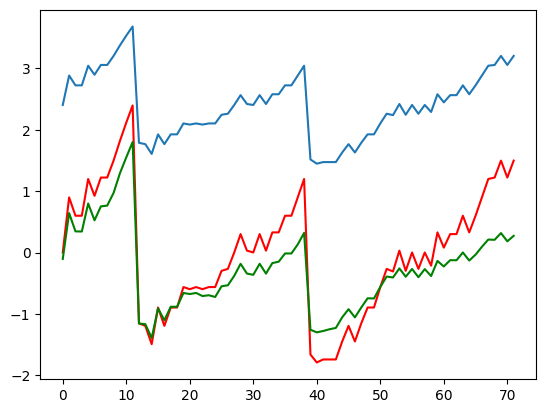

In [6]:
X_train.shape
plt.plot(X_train[0])
X_train_scaled =TimeSeriesScalerMeanVariance().fit_transform(X_train)
X_train_scaled_sklearn = StandardScaler().fit_transform(X_train)
plt.plot(X_train_scaled[0], color='red')
plt.plot(X_train_scaled_sklearn[0], color='green')